# 날씨 x 택시 수요 탄력성 분석
- **내부 데이터**: D012 (요금정보) - 승차건수, 시간대, 요금
- **외부 데이터**: 기상청 ASOS (Open-Meteo) - 시간별 기온, 강수량, 강설, 풍속
- **분석 목표**: 날씨 조건별 택시 수요 변동 패턴, 수요 탄력성 계수 산출

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
# plt.rcParams['font.family'] = 'AppleGothic'  # Mac
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

## 1. 데이터 로드

In [24]:
# === 경로 설정 (폐쇄망 환경에 맞게 수정) ===
D012_PATH = r"D:\coding-assistant\tmoney\tmoney\DC_TBYXD012.csv"  # 요금정보 (내부 데이터)
WEATHER_PATH = r"D:\coding-assistant\tmoney\tmoney\external_data\weather\seoul_weather_2018_2026.csv"

# 날씨 데이터 로드
weather = pd.read_csv(WEATHER_PATH, parse_dates=['datetime'])
weather['date'] = weather['datetime'].dt.date
weather['hour'] = weather['datetime'].dt.hour
weather['year_month'] = weather['datetime'].dt.to_period('M')

print(f"날씨 데이터: {len(weather):,}행, {weather['datetime'].min()} ~ {weather['datetime'].max()}")
weather.head()

날씨 데이터: 73,008행, 2018-01-01 00:00:00 ~ 2026-04-30 23:00:00


,datetime,temperature,humidity,precipitation,snowfall,wind_speed,weather_code,date,hour,year_month
0,2018-01-01 00:00:00,-4.7,53,0.0,0.0,10.4,0,2018-01-01,0,2018-01
1,2018-01-01 01:00:00,-4.8,50,0.0,0.0,9.3,0,2018-01-01,1,2018-01
2,2018-01-01 02:00:00,-5.8,55,0.0,0.0,9.4,0,2018-01-01,2,2018-01
3,2018-01-01 03:00:00,-5.6,50,0.0,0.0,4.6,0,2018-01-01,3,2018-01
4,2018-01-01 04:00:00,-6.1,51,0.0,0.0,5.4,0,2018-01-01,4,2018-01


In [25]:
# D012 로드 (대용량이므로 필요한 컬럼만)
d012_cols = ['RIDE_DTIME', 'ALIGHT_DTIME', 'PAY_AMT', 'RIDE_DIST', 'RIDE_A_CD', 'ALIGHT_A_CD']
d012 = pd.read_csv(D012_PATH, usecols=d012_cols, dtype={'RIDE_DTIME': str, 'ALIGHT_DTIME': str})

# 날짜/시간 파싱
d012['ride_datetime'] = pd.to_datetime(d012['RIDE_DTIME'], format='%Y%m%d%H%M%S', errors='coerce')
d012['date'] = d012['ride_datetime'].dt.date
d012['hour'] = d012['ride_datetime'].dt.hour
d012['weekday'] = d012['ride_datetime'].dt.dayofweek  # 0=월 ~ 6=일
d012['is_weekend'] = d012['weekday'].isin([5, 6]).astype(int)

# 소요시간 계산 (분)
d012['alight_datetime'] = pd.to_datetime(d012['ALIGHT_DTIME'], format='%Y%m%d%H%M%S', errors='coerce')
d012['duration_min'] = (d012['alight_datetime'] - d012['ride_datetime']).dt.total_seconds() / 60

print(f"D012 데이터: {len(d012):,}행")
print(f"기간: {d012['ride_datetime'].min()} ~ {d012['ride_datetime'].max()}")
d012.head()

D012 데이터: 60,000,000행
기간: 2018-01-01 00:00:06 ~ 2026-05-01 00:14:30


,RIDE_DTIME,ALIGHT_DTIME,RIDE_DIST,PAY_AMT,RIDE_A_CD,ALIGHT_A_CD,ride_datetime,date,hour,weekday,is_weekend,alight_datetime,duration_min
0,20210707005346,20210707011446,3574,5600,1129000000,1168000000,2021-07-07 00:53:46,2021-07-07,0,2,0,2021-07-07 01:14:46,21.0
1,20220101032136,20220101033436,2187,10100,1135000000,1156000000,2022-01-01 03:21:36,2022-01-01,3,5,1,2022-01-01 03:34:36,13.0
2,20250911051822,20250911053322,4333,8300,1159000000,1174000000,2025-09-11 05:18:22,2025-09-11,5,3,0,2025-09-11 05:33:22,15.0
3,20190523081834,20190523082334,1905,5300,1174000000,1111000000,2019-05-23 08:18:34,2019-05-23,8,3,0,2019-05-23 08:23:34,5.0
4,20220830201134,20220830202734,3707,6100,1120000000,1159000000,2022-08-30 20:11:34,2022-08-30,20,1,0,2022-08-30 20:27:34,16.0


## 2. 시간대별 승차건수 집계 + 날씨 조인

In [26]:
# 시간대별 승차건수 & 평균요금 집계
hourly_demand = d012.groupby(['date', 'hour']).agg(
    ride_count=('PAY_AMT', 'count'),
    avg_fare=('PAY_AMT', 'mean'),
    avg_dist=('RIDE_DIST', 'mean'),
    avg_duration=('duration_min', 'mean'),
    is_weekend=('is_weekend', 'first')
).reset_index()

hourly_demand['date'] = pd.to_datetime(hourly_demand['date'])
weather['date_dt'] = pd.to_datetime(weather['date'])

# 날씨 조인 (날짜 + 시간)
merged = hourly_demand.merge(
    weather[['date_dt', 'hour', 'temperature', 'humidity', 'precipitation', 'snowfall', 'wind_speed', 'weather_code']],
    left_on=['date', 'hour'],
    right_on=['date_dt', 'hour'],
    how='inner'
)

print(f"조인 결과: {len(merged):,}행")
merged.head()

조인 결과: 73,008행


,date,hour,ride_count,avg_fare,avg_dist,avg_duration,is_weekend,date_dt,temperature,humidity,precipitation,snowfall,wind_speed,weather_code
0,2018-01-01,0,312,7055.128205,3466.365385,17.695513,0,2018-01-01,-4.7,53,0.0,0.0,10.4,0
1,2018-01-01,1,344,7002.325581,3391.561047,17.877907,0,2018-01-01,-4.8,50,0.0,0.0,9.3,0
2,2018-01-01,2,352,7312.500000,3332.196023,17.951705,0,2018-01-01,-5.8,55,0.0,0.0,9.4,0
3,2018-01-01,3,407,7014.496314,3446.525799,18.574939,0,2018-01-01,-5.6,50,0.0,0.0,4.6,0
4,2018-01-01,4,350,7095.714286,3445.614286,17.860000,0,2018-01-01,-6.1,51,0.0,0.0,5.4,0


## 3. 날씨 조건 분류

In [27]:
# 날씨 조건 분류
def classify_weather(row):
    if row['snowfall'] > 0:
        return '눈'
    elif row['precipitation'] >= 10:
        return '강한비(10mm+)'
    elif row['precipitation'] >= 1:
        return '보통비(1~10mm)'
    elif row['precipitation'] > 0:
        return '약한비(<1mm)'
    else:
        return '맑음'

merged['weather_condition'] = merged.apply(classify_weather, axis=1)

# 기온 구간
merged['temp_bin'] = pd.cut(merged['temperature'], 
                            bins=[-30, -10, 0, 10, 20, 30, 45],
                            labels=['-10도이하', '-10~0도', '0~10도', '10~20도', '20~30도', '30도이상'])

print(merged['weather_condition'].value_counts())
print()
print(merged['temp_bin'].value_counts().sort_index())

weather_condition
맑음             62719
약한비(<1mm)       6664
보통비(1~10mm)     2845
눈                703
강한비(10mm+)        77
Name: count, dtype: int64

temp_bin
-10도이하     1091
-10~0도    12685
0~10도     18789
10~20도    19375
20~30도    19587
30도이상      1481
Name: count, dtype: int64


## 4. 날씨 조건별 택시 수요 비교

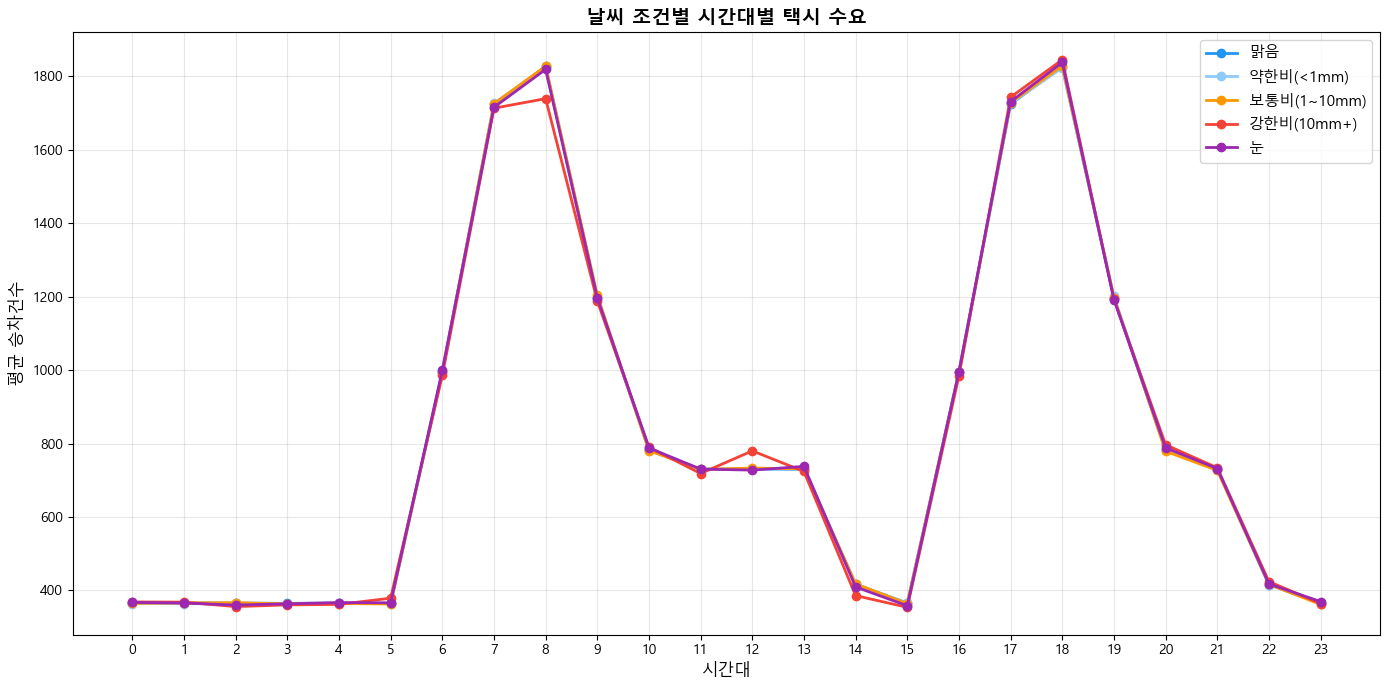

In [28]:
# 날씨 조건별 시간대별 평균 승차건수
weather_hourly = merged.groupby(['weather_condition', 'hour'])['ride_count'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 7))
colors = {'맑음': '#2196F3', '약한비(<1mm)': '#90CAF9', '보통비(1~10mm)': '#FF9800', 
          '강한비(10mm+)': '#F44336', '눈': '#9C27B0'}

for cond in ['맑음', '약한비(<1mm)', '보통비(1~10mm)', '강한비(10mm+)', '눈']:
    subset = weather_hourly[weather_hourly['weather_condition'] == cond]
    if len(subset) > 0:
        ax.plot(subset['hour'], subset['ride_count'], marker='o', 
                label=cond, color=colors.get(cond, 'gray'), linewidth=2)

ax.set_xlabel('시간대', fontsize=12)
ax.set_ylabel('평균 승차건수', fontsize=12)
ax.set_title('날씨 조건별 시간대별 택시 수요', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(range(24))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
# 날씨 조건별 수요 변화율 (맑음 대비)
baseline = merged[merged['weather_condition'] == '맑음'].groupby('hour')['ride_count'].mean()

print("=" * 60)
print("날씨 조건별 택시 수요 변화율 (맑음 대비)")
print("=" * 60)

summary_rows = []
for cond in ['약한비(<1mm)', '보통비(1~10mm)', '강한비(10mm+)', '눈']:
    cond_avg = merged[merged['weather_condition'] == cond].groupby('hour')['ride_count'].mean()
    common_hours = baseline.index.intersection(cond_avg.index)
    if len(common_hours) > 0:
        change = ((cond_avg[common_hours] / baseline[common_hours]) - 1) * 100
        avg_change = change.mean()
        peak_hour = change.idxmax()
        peak_change = change.max()
        summary_rows.append({
            '날씨조건': cond,
            '전체 평균 변화율(%)': round(avg_change, 1),
            '최대 변화 시간대': f'{peak_hour}시',
            '최대 변화율(%)': round(peak_change, 1)
        })

summary_df = pd.DataFrame(summary_rows)
summary_df

날씨 조건별 택시 수요 변화율 (맑음 대비)


,날씨조건,전체 평균 변화율(%),최대 변화 시간대,최대 변화율(%)
0,약한비(<1mm),-0.0,19시,0.4
1,보통비(1~10mm),-0.0,9시,0.5
2,강한비(10mm+),-0.3,12시,6.7
3,눈,0.0,23시,1.2


## 5. 강수량 구간별 수요 탄력성

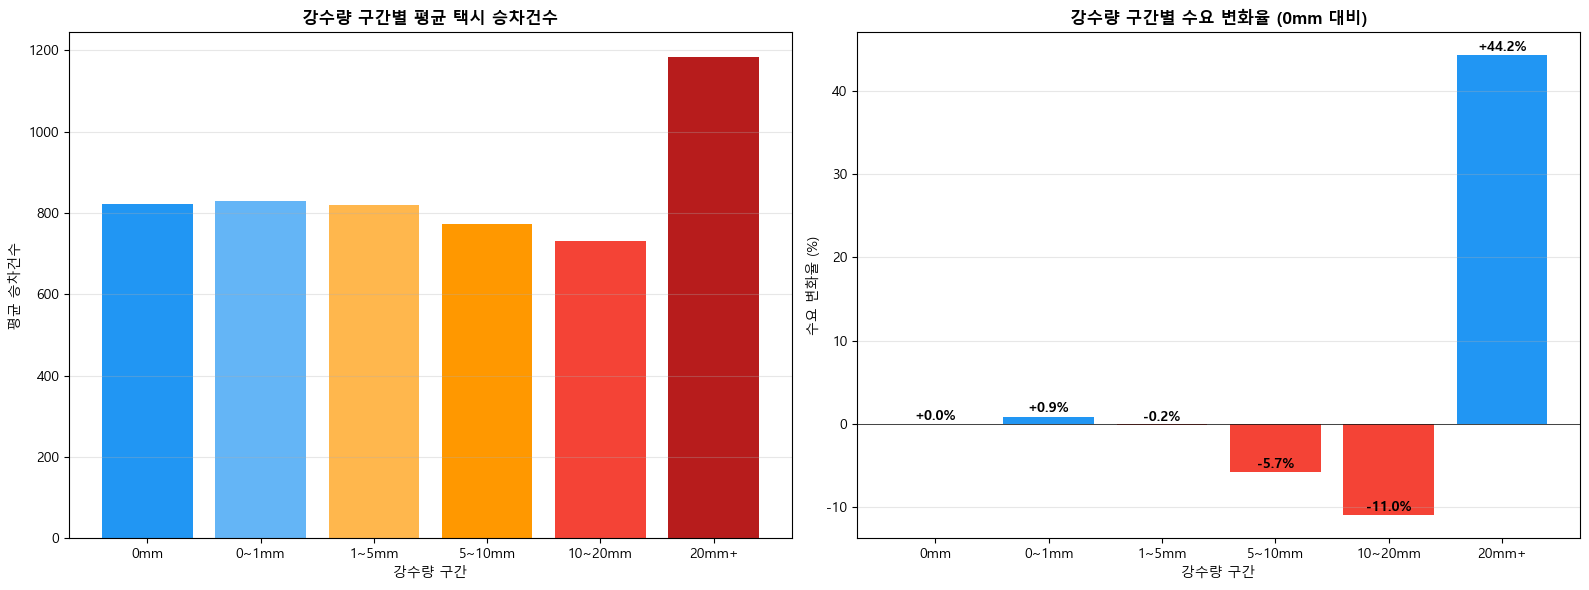

,precip_bin,avg_rides,change_pct,count
0,0mm,821.398438,0.000000,62725
1,0~1mm,828.605959,0.877470,7451
2,1~5mm,819.974085,-0.173406,2431
3,5~10mm,774.322086,-5.731244,326
4,10~20mm,731.117647,-10.991108,68
5,20mm+,1184.714286,44.231378,7


In [30]:
# 강수량 구간별 평균 승차건수
merged['precip_bin'] = pd.cut(merged['precipitation'], 
                              bins=[-0.1, 0, 1, 5, 10, 20, 100],
                              labels=['0mm', '0~1mm', '1~5mm', '5~10mm', '10~20mm', '20mm+'])

precip_demand = merged.groupby('precip_bin', observed=True).agg(
    avg_rides=('ride_count', 'mean'),
    avg_fare=('avg_fare', 'mean'),
    count=('ride_count', 'count')
).reset_index()

# 탄력성 계산 (0mm 대비)
base_rides = precip_demand.loc[precip_demand['precip_bin'] == '0mm', 'avg_rides'].values[0]
precip_demand['change_pct'] = ((precip_demand['avg_rides'] / base_rides) - 1) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 좌: 강수량별 평균 승차건수
bars = ax1.bar(precip_demand['precip_bin'].astype(str), precip_demand['avg_rides'], 
               color=['#2196F3', '#64B5F6', '#FFB74D', '#FF9800', '#F44336', '#B71C1C'])
ax1.set_xlabel('강수량 구간')
ax1.set_ylabel('평균 승차건수')
ax1.set_title('강수량 구간별 평균 택시 승차건수', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# 우: 변화율
colors = ['#2196F3' if v >= 0 else '#F44336' for v in precip_demand['change_pct']]
ax2.bar(precip_demand['precip_bin'].astype(str), precip_demand['change_pct'], color=colors)
ax2.set_xlabel('강수량 구간')
ax2.set_ylabel('수요 변화율 (%)')
ax2.set_title('강수량 구간별 수요 변화율 (0mm 대비)', fontweight='bold')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.grid(True, alpha=0.3, axis='y')

for i, v in enumerate(precip_demand['change_pct']):
    ax2.text(i, v + 0.5, f'{v:+.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

precip_demand[['precip_bin', 'avg_rides', 'change_pct', 'count']]

## 6. 기온 구간별 수요 패턴

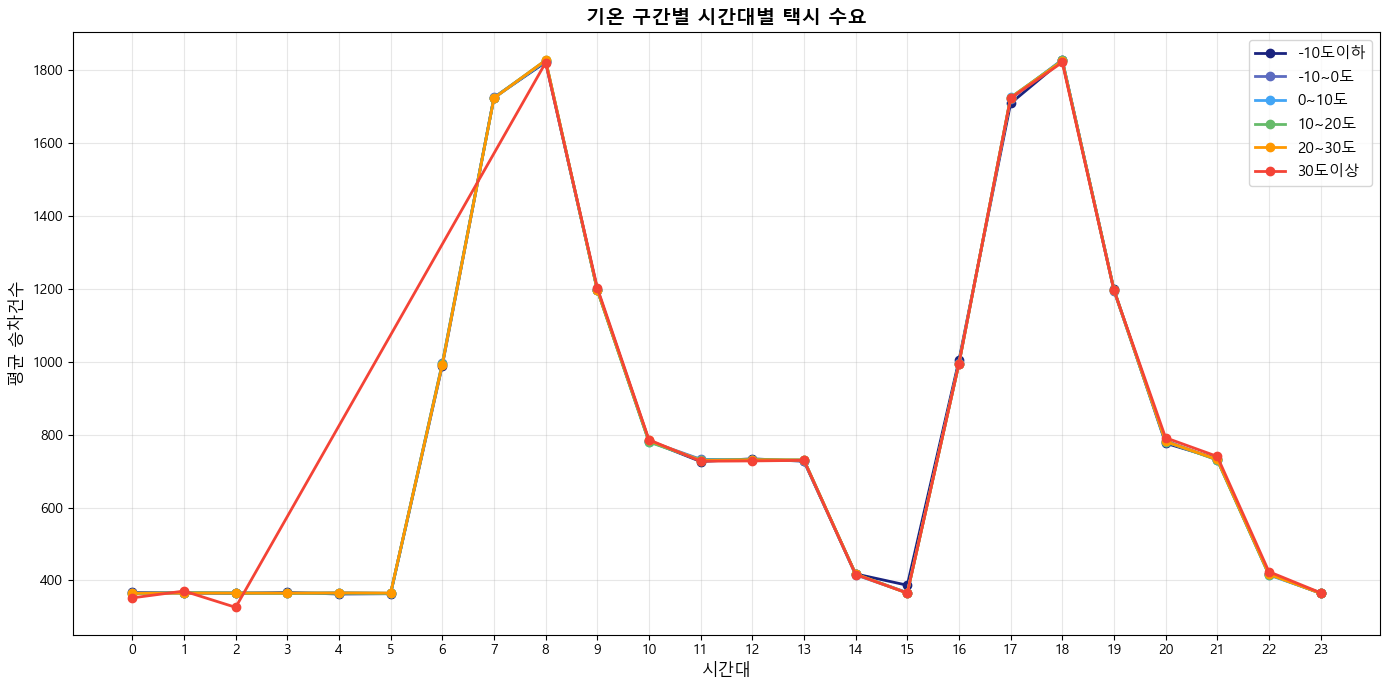

In [31]:
# 기온 구간별 시간대별 수요
temp_hourly = merged.groupby(['temp_bin', 'hour'], observed=True)['ride_count'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 7))
temp_colors = {'-10도이하': '#1A237E', '-10~0도': '#5C6BC0', '0~10도': '#42A5F5',
               '10~20도': '#66BB6A', '20~30도': '#FF9800', '30도이상': '#F44336'}

for temp in ['-10도이하', '-10~0도', '0~10도', '10~20도', '20~30도', '30도이상']:
    subset = temp_hourly[temp_hourly['temp_bin'] == temp]
    if len(subset) > 0:
        ax.plot(subset['hour'], subset['ride_count'], marker='o', 
                label=temp, color=temp_colors.get(temp, 'gray'), linewidth=2)

ax.set_xlabel('시간대', fontsize=12)
ax.set_ylabel('평균 승차건수', fontsize=12)
ax.set_title('기온 구간별 시간대별 택시 수요', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(range(24))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. 평일 vs 주말 x 날씨 교차 분석

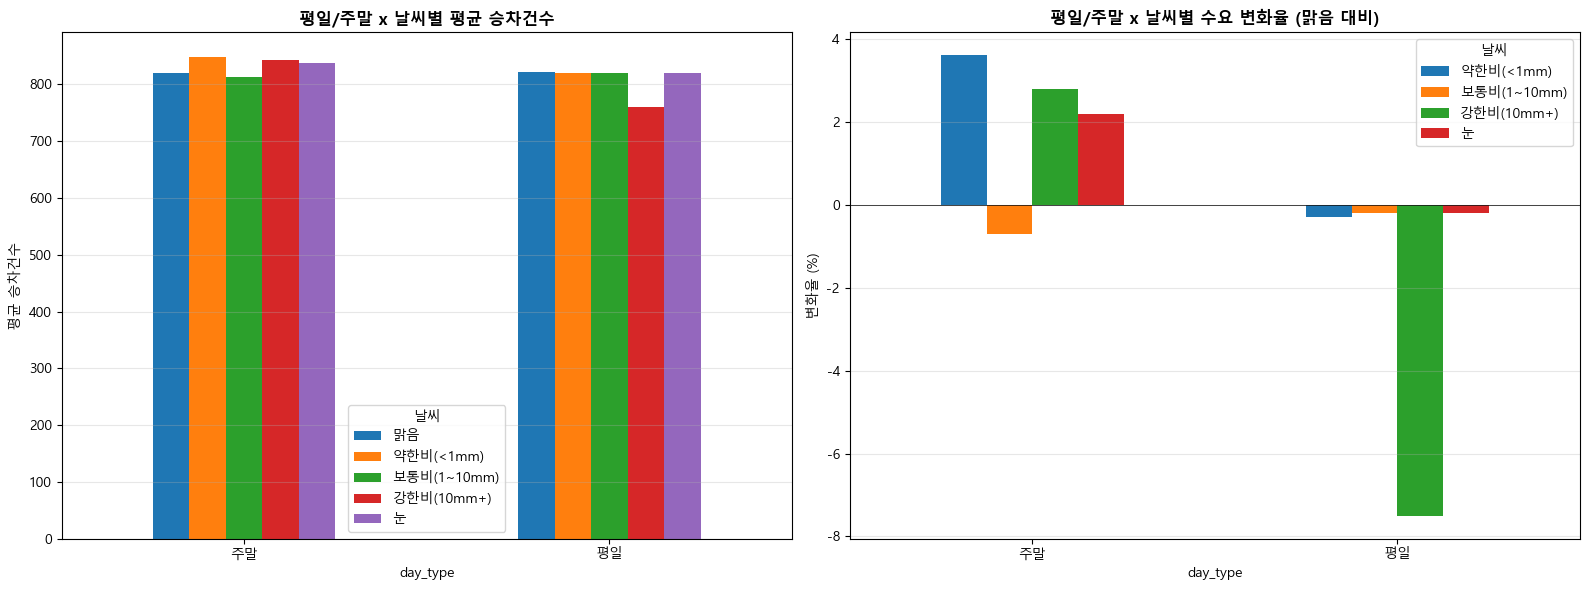


수요 변화율 (맑음 대비, %)


weather_condition,맑음,약한비(<1mm),보통비(1~10mm),강한비(10mm+),눈
day_type,,,,,
주말,0.0,3.6,-0.7,2.8,2.2
평일,0.0,-0.3,-0.2,-7.5,-0.2


In [32]:
# 평일/주말 x 날씨 조건 크로스탭
merged['day_type'] = merged['is_weekend'].map({0: '평일', 1: '주말'})

cross = merged.groupby(['day_type', 'weather_condition'])['ride_count'].mean().unstack(fill_value=0)
cross = cross[['맑음', '약한비(<1mm)', '보통비(1~10mm)', '강한비(10mm+)', '눈']]

# 변화율 계산
cross_pct = cross.div(cross['맑음'], axis=0).subtract(1).multiply(100).round(1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

cross.plot(kind='bar', ax=ax1, rot=0)
ax1.set_title('평일/주말 x 날씨별 평균 승차건수', fontweight='bold')
ax1.set_ylabel('평균 승차건수')
ax1.legend(title='날씨')
ax1.grid(True, alpha=0.3, axis='y')

cross_pct.drop(columns='맑음').plot(kind='bar', ax=ax2, rot=0)
ax2.set_title('평일/주말 x 날씨별 수요 변화율 (맑음 대비)', fontweight='bold')
ax2.set_ylabel('변화율 (%)')
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.legend(title='날씨')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n수요 변화율 (맑음 대비, %)")
cross_pct

## 8. 월별 추이 (시계열)

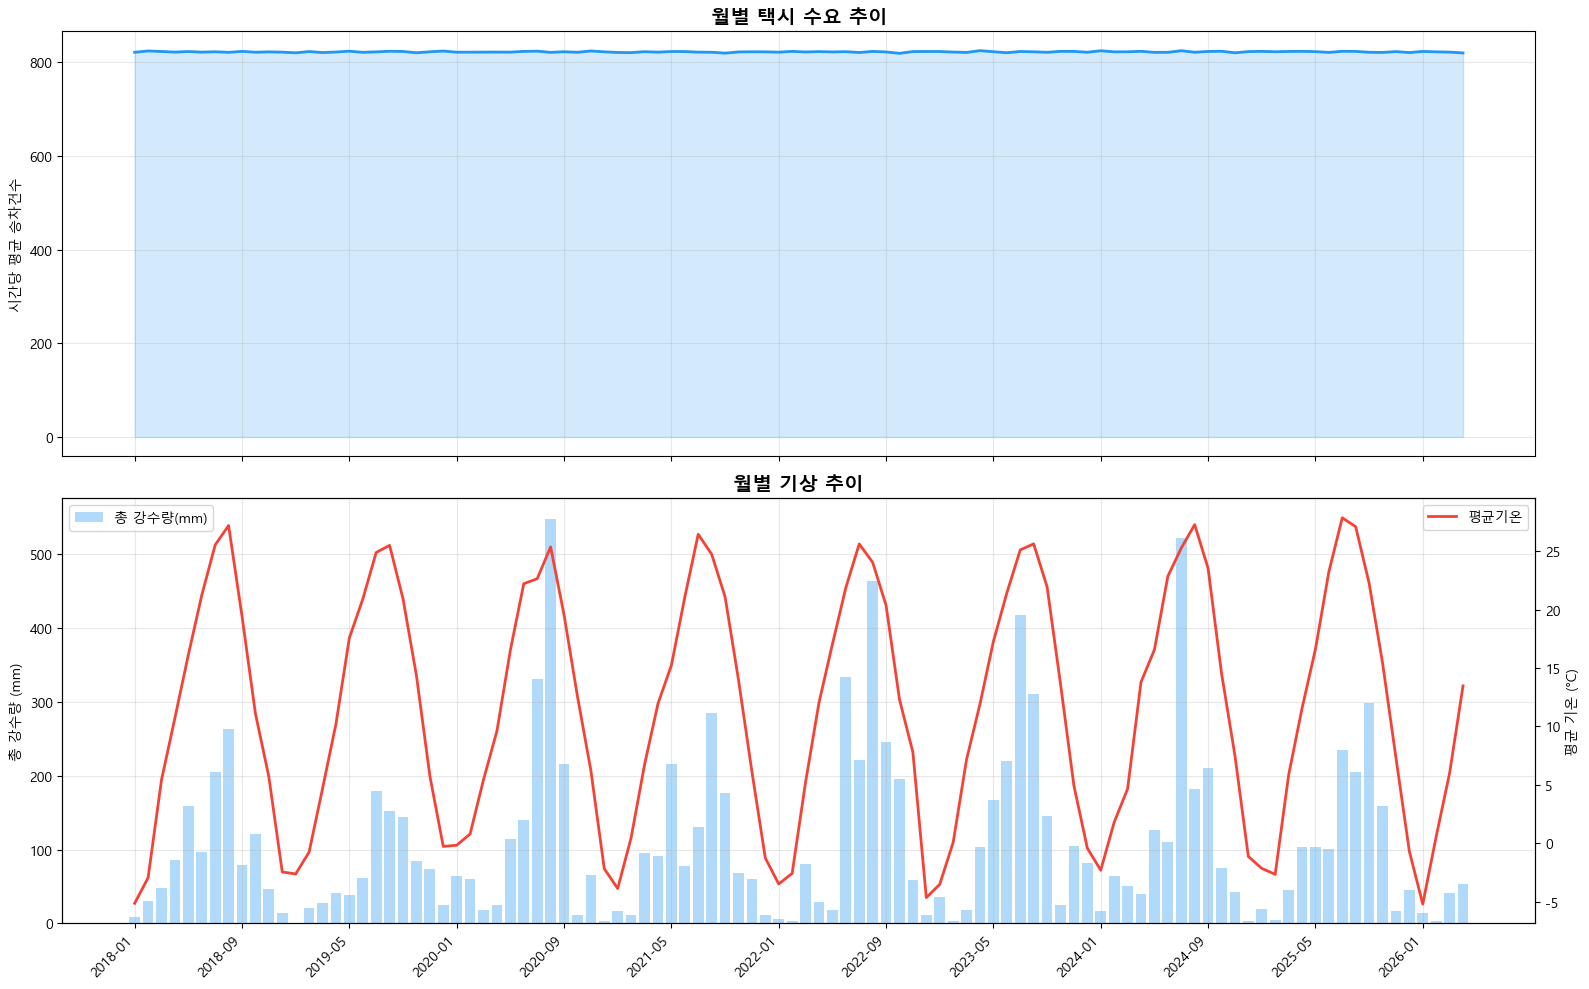

In [33]:
# 월별 택시 수요 + 강수일수 시계열
merged['year_month'] = merged['date'].dt.to_period('M')

monthly = merged.groupby('year_month').agg(
    total_rides=('ride_count', 'sum'),
    avg_rides_per_hour=('ride_count', 'mean'),
    rainy_hours=('precipitation', lambda x: (x > 0).sum()),
    avg_temp=('temperature', 'mean'),
    total_precip=('precipitation', 'sum')
).reset_index()

monthly['year_month_str'] = monthly['year_month'].astype(str)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# 상: 월별 평균 승차건수
ax1.plot(monthly['year_month_str'], monthly['avg_rides_per_hour'], 
         color='#2196F3', linewidth=2)
ax1.fill_between(range(len(monthly)), monthly['avg_rides_per_hour'], alpha=0.2, color='#2196F3')
ax1.set_ylabel('시간당 평균 승차건수')
ax1.set_title('월별 택시 수요 추이', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 하: 월별 강수량 + 기온
ax2_twin = ax2.twinx()
ax2.bar(range(len(monthly)), monthly['total_precip'], alpha=0.5, color='#64B5F6', label='총 강수량(mm)')
ax2_twin.plot(range(len(monthly)), monthly['avg_temp'], color='#F44336', linewidth=2, label='평균기온')
ax2.set_ylabel('총 강수량 (mm)')
ax2_twin.set_ylabel('평균 기온 (°C)')
ax2.set_title('월별 기상 추이', fontsize=14, fontweight='bold')

# x축 라벨 간소화
tick_positions = range(0, len(monthly), max(1, len(monthly)//12))
ax2.set_xticks(list(tick_positions))
ax2.set_xticklabels([monthly['year_month_str'].iloc[i] for i in tick_positions], rotation=45, ha='right')

ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. 수요 탄력성 계수 산출

강수량-택시수요 탄력성 분석 결과
탄력성 계수 (slope): -0.0254
R² (결정계수): 0.0006
p-value: 1.53e-02
해석: 강수량 1% 증가 시 택시 수요 -0.03% 변화


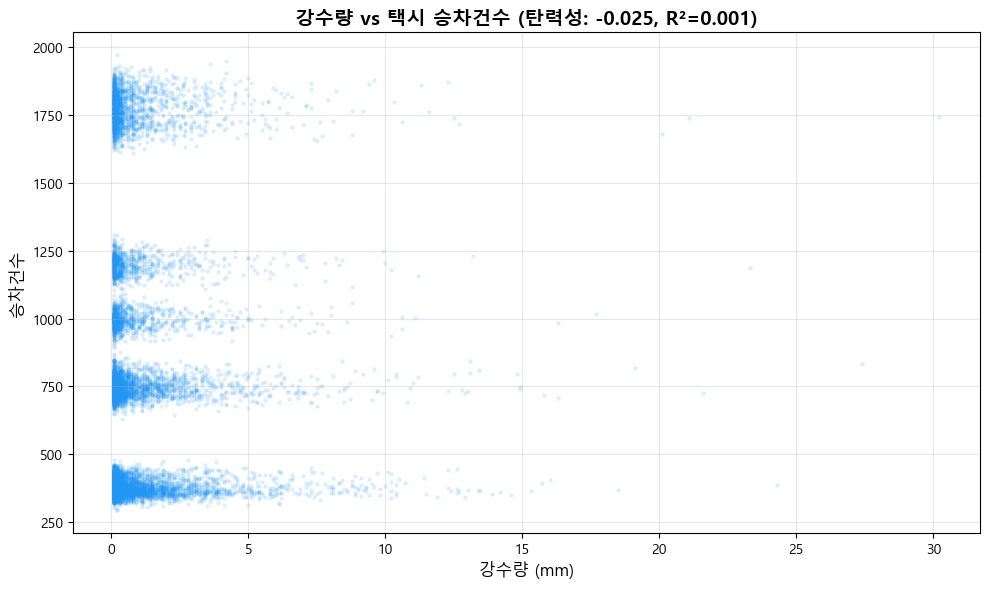

In [34]:
from scipy import stats

# 강수량 vs 승차건수 상관분석
rainy = merged[merged['precipitation'] > 0].copy()

# 로그 변환 (탄력성 = d(log Q) / d(log P))
rainy['log_precip'] = np.log1p(rainy['precipitation'])
rainy['log_rides'] = np.log1p(rainy['ride_count'])

# 회귀분석
slope, intercept, r_value, p_value, std_err = stats.linregress(rainy['log_precip'], rainy['log_rides'])

print("=" * 50)
print("강수량-택시수요 탄력성 분석 결과")
print("=" * 50)
print(f"탄력성 계수 (slope): {slope:.4f}")
print(f"R² (결정계수): {r_value**2:.4f}")
print(f"p-value: {p_value:.2e}")
print(f"해석: 강수량 1% 증가 시 택시 수요 {slope:.2f}% 변화")

# 산점도
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(rainy['precipitation'], rainy['ride_count'], alpha=0.1, s=5, color='#2196F3')
ax.set_xlabel('강수량 (mm)', fontsize=12)
ax.set_ylabel('승차건수', fontsize=12)
ax.set_title(f'강수량 vs 택시 승차건수 (탄력성: {slope:.3f}, R²={r_value**2:.3f})', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. 주요 인사이트 요약

In [35]:
# 전체 요약 테이블
print("=" * 70)
print("날씨 x 택시 수요 분석 요약")
print("=" * 70)

# 날씨 조건별 요약
weather_summary = merged.groupby('weather_condition').agg(
    평균_승차건수=('ride_count', 'mean'),
    평균_요금=('avg_fare', 'mean'),
    평균_거리=('avg_dist', 'mean'),
    관측_시간수=('ride_count', 'count')
).round(1)

# 맑음 대비 변화율
base = weather_summary.loc['맑음', '평균_승차건수']
weather_summary['수요_변화율(%)'] = ((weather_summary['평균_승차건수'] / base) - 1) * 100
weather_summary['수요_변화율(%)'] = weather_summary['수요_변화율(%)'].round(1)

weather_summary

날씨 x 택시 수요 분석 요약


,평균_승차건수,평균_요금,평균_거리,관측_시간수,수요_변화율(%)
weather_condition,,,,,
강한비(10mm+),774.0,7116.1,3387.8,77,-5.8
눈,825.8,7112.3,3378.3,703,0.5
맑음,821.4,7114.7,3379.8,62719,0.0
보통비(1~10mm),818.7,7115.3,3377.3,2845,-0.3
약한비(<1mm),827.6,7114.5,3379.9,6664,0.8
